In [1]:
from sunpy.net import Fido, attrs as a
import sunpy.map
from sunpy.time import parse_time
import sunpy.timeseries
import sunpy.data.sample
from sunpy.coordinates import frames, get_horizons_coord, get_body_heliographic_stonyhurst
from sunpy.coordinates import SphericalScreen
import sunpy_soar

from astropy import units as u 
from astropy.coordinates import SkyCoord
from astropy.visualization import AsymmetricPercentileInterval, ImageNormalize, LogStretch, AsinhStretch
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import dates

In [2]:
aia_file = r"C:\Users\Admin\OneDrive - Dublin City University\Dunsink Dr. Nedal Internship\solar_shell_gui\Data\AIA\193A\lowres\lv1\aia.lev1.193A_2011_08_08T18_00_07.84Z.image_lev1.fits"
aia_map = sunpy.map.Map(aia_file)

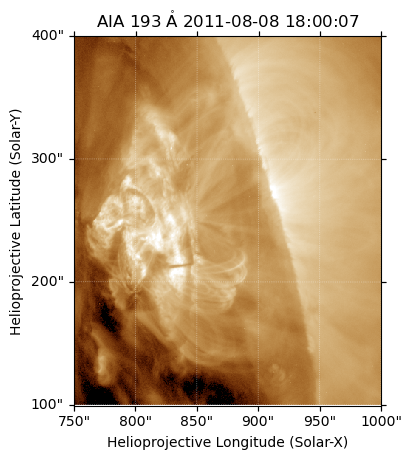

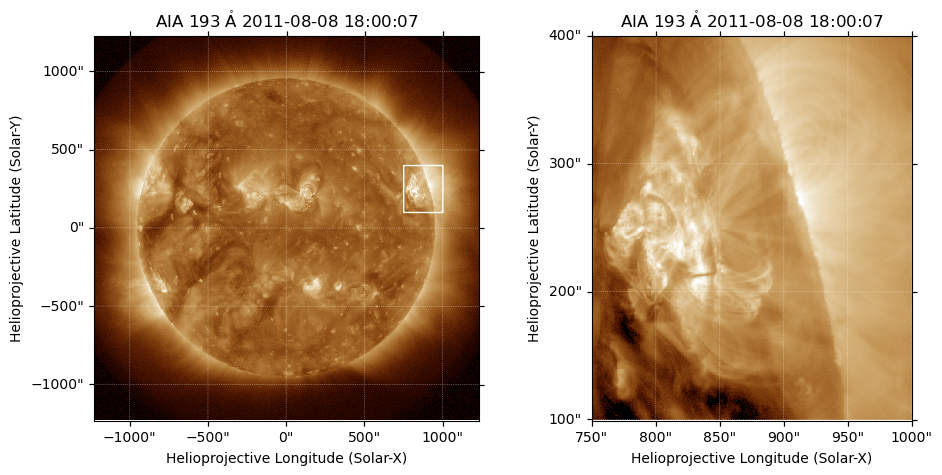

In [3]:
bottom_left = SkyCoord(750*u.arcsec, 100*u.arcsec, frame=aia_map.coordinate_frame)
top_right = SkyCoord(1000*u.arcsec, 400*u.arcsec, frame=aia_map.coordinate_frame)
submap = aia_map.submap(bottom_left, top_right=top_right)
fig = plt.figure()
submap.plot(clip_interval=[1, 99.9]*u.percent)


fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1,2,1,projection=aia_map)
aia_map.plot(axes=ax1, clip_interval=(0.1, 99.99)*u.percent)

aia_map.draw_quadrangle(bottom_left, 
                        top_right=top_right, 
                        axes=ax1)

ax2 = fig.add_subplot(1,2,2,projection=submap)
submap.plot(clip_interval=(0.5, 99.95)*u.percent)

In [7]:
import glob
import os

# 1. Define the folder where your files live
folder_path = r"C:\Users\Admin\OneDrive - Dublin City University\Dunsink Dr. Nedal Internship\solar_shell_gui\Data\AIA\193A\lowres\lv1"

# 2. Tell glob to find every FITS file in that folder
# The '*' acts as a wildcard, catching any date/time string
search_pattern = os.path.join(folder_path, "aia.lev1.193A_2011_08_08*.fits")
f = glob.glob(search_pattern)

# 3. Sort the list chronologically 
# (Since the date format YYYY_MM_DDTHH_MM_SS is naturally alphabetical, sorting works perfectly)
f.sort()

print(f"Found {len(f)} files.")
# Now 'f' contains the exact same list of paths you had, but generated automatically!

Found 24 files.


In [6]:
#run_diff function from final.py
def create_running_diff_maps(self):
    self.set_processed_maps_from_loaded()

    if len(self.processed_maps) < 6:
            QMessageBox.warning(self, 'Warning',
                                'Need at least 6 images for running difference.')
            return

    self.running_diff_maps = []
    n = len(self.processed_maps) - 5
    self.progress.setVisible(True)
    self.progress.setRange(0, n)
    self.progress.setValue(0)
    self.label.setText('Creating running-difference maps...')
    QApplication.processEvents()

    vmin_text = self.vmin_input.text()
    vmax_text = self.vmax_input.text()
    v1 = float(vmin_text) if vmin_text else -50.0
    v2 = float(vmax_text) if vmax_text else 50.0
        
    for idx, i in enumerate(range(5, len(self.processed_maps))):
        try:
            m0 = self.processed_maps[i-5]
            m1 = self.processed_maps[i]
            diff = m1.quantity - m0.quantity
            smoothed = ndimage.gaussian_filter(diff, sigma=[3, 3])
            diff_map = sunpy.map.Map(smoothed, m1.meta)
            diff_map.plot_settings['norm'] = colors.Normalize(vmin=v1, vmax=v2)
            self.running_diff_maps.append(diff_map)
        except Exception as e:
            print(f'Error creating diff map {i}: {e}')
        self.progress.setValue(idx + 1)
        QApplication.processEvents()

    self.maps = self.running_diff_maps
    self.current_index = 0
    self.progress.setVisible(False)
    if self.maps:
        self.plot_map(self.maps[0])
    self.label.setText(f'Created {len(self.running_diff_maps)} running difference maps.')

def draw_ellipse(self, x0, y0, current_map=None, redraw_canvas=True):
    try:
        if not self.maps:
            self.label.setText('No map to draw ellipse on.')
            return

        if current_map is None:
            current_map = self.maps[self.current_index]

        if not self.canvas.figure.axes:
            self.plot_map(current_map)
            ax = self.canvas.figure.axes[0]
        else:
            ax = self.canvas.figure.axes[0]

        if self.ellipse_artist is not None and self.ellipse_artist in ax.lines:
            self.ellipse_artist.remove()
            self.ellipse_artist = None
        elif self.ellipse_artist is not None:
            self.ellipse_artist = None

        self.ellipse_center = (x0, y0)

        a = self.a_slider.value()
        b = self.b_slider.value()

        x_ell = x0 + a * np.cos(self.theta)
        y_ell = y0 + b * np.sin(self.theta)

        coords = SkyCoord(x_ell * u.arcsec, y_ell * u.arcsec,
                          frame=current_map.coordinate_frame)

        self.ellipse_artist, = ax.plot_coord(coords, color='red', lw=2)

        if redraw_canvas:
            self.canvas.draw()
            self.label.setText('Ellipse updated.')
    except Exception as e:
        self.label.setText(f'Ellipse error: {str(e)}')

Found 24 files.
Successfully created 19 running difference maps.


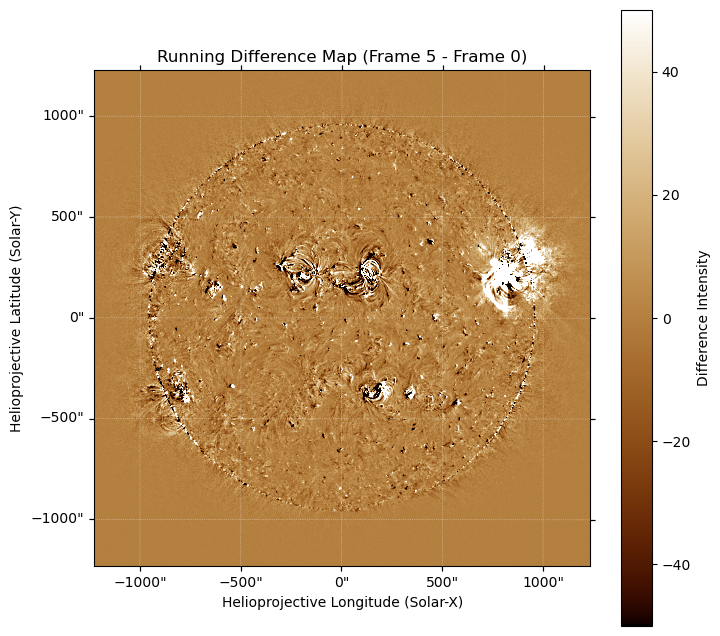

In [8]:
import glob
import os
import sunpy.map
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- 1. Find the files (Your code) ---
folder_path = r"C:\Users\Admin\OneDrive - Dublin City University\Dunsink Dr. Nedal Internship\solar_shell_gui\Data\AIA\193A\lowres\lv1"
search_pattern = os.path.join(folder_path, "aia.lev1.193A_2011_08_08*.fits")
f = glob.glob(search_pattern)
f.sort()

print(f"Found {len(f)} files.")

# --- 2. Load the files into a list of SunPy Maps ---
# This acts exactly like 'self.processed_maps' in your GUI
processed_maps = [sunpy.map.Map(filepath) for filepath in f]

# --- 3. Calculate the Running Differences ---
running_diff_maps = []

# Using your original limits
v1, v2 = -50.0, 50.0

# Start the loop at index 5, just like in your GUI class
for i in range(5, len(processed_maps)):
    try:
        # Grab the older map (5 frames ago) and the current map
        m0 = processed_maps[i-5]
        m1 = processed_maps[i]
        
        # Calculate the difference
        diff = m1.quantity - m0.quantity
        
        # Apply Gaussian smoothing to reduce noise
        smoothed = ndimage.gaussian_filter(diff, sigma=[3, 3])
        
        # Create a new SunPy map using the smoothed data and current metadata
        diff_map = sunpy.map.Map(smoothed, m1.meta)
        
        # Apply normalization and colormap
        diff_map.plot_settings['norm'] = colors.Normalize(vmin=v1, vmax=v2)
        diff_map.plot_settings['cmap'] = 'sdoaia193' 
        
        running_diff_maps.append(diff_map)
        
    except Exception as e:
        print(f"Error creating diff map at index {i}: {e}")

print(f"Successfully created {len(running_diff_maps)} running difference maps.")

# --- 4. Plot the very first difference map to verify ---
if running_diff_maps:
    fig = plt.figure(figsize=(8, 8))
    # Note: We use the WCS (World Coordinate System) of the map for the projection
    ax = fig.add_subplot(111, projection=running_diff_maps[0])
    running_diff_maps[0].plot(axes=ax)
    plt.colorbar(label='Difference Intensity')
    plt.title(f'Running Difference Map (Frame 5 - Frame 0)')
    plt.show()

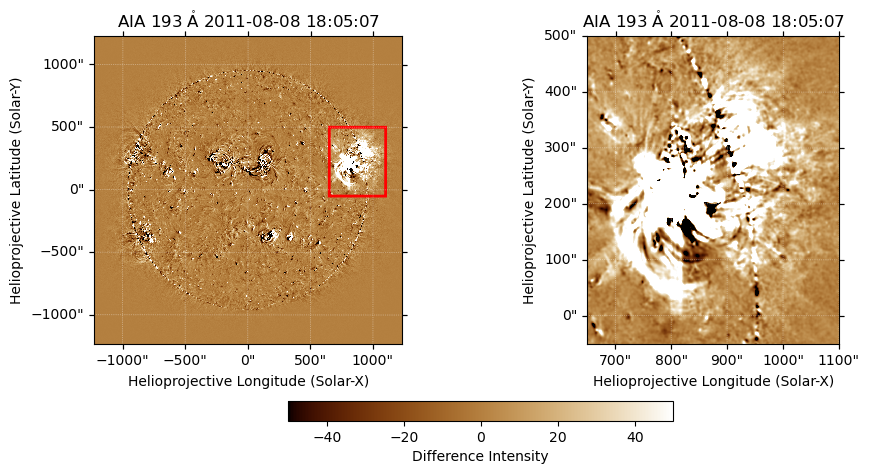

In [16]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

# 1. Select the specific running difference map you want to plot
# Let's use the first one in the list for this example
rd_map = running_diff_maps[0]

# 2. Define the coordinates using the frame of our difference map
bottom_left = SkyCoord(650*u.arcsec, -50*u.arcsec, frame=rd_map.coordinate_frame)
top_right = SkyCoord(1100*u.arcsec, 500*u.arcsec, frame=rd_map.coordinate_frame)

# 3. Create the submap (the cropped region)
rd_submap = rd_map.submap(bottom_left, top_right=top_right)

# 4. Set up the figure for side-by-side plotting
fig = plt.figure(figsize=(11, 5))

# --- Plot 1: Full map with the quadrangle box ---
ax1 = fig.add_subplot(1, 2, 1, projection=rd_map)
# Notice we removed clip_interval so it uses the -50 to 50 limits we already set
rd_map.plot(axes=ax1) 
rd_map.draw_quadrangle(bottom_left, 
                       top_right=top_right, 
                       axes=ax1, 
                       edgecolor='red', # Added red so it stands out against the diff map
                       lw=2)

# --- Plot 2: The cropped submap ---
ax2 = fig.add_subplot(1, 2, 2, projection=rd_submap)
rd_submap.plot(axes=ax2)

plt.colorbar(label='Difference Intensity', ax=[ax1, ax2], orientation='horizontal', fraction=0.05)
plt.show()

In [21]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map

# 1. Create an empty list to hold our new cropped maps
rd_cutout_list = []

# 2. Loop directly through the running difference maps we already created
for rd_map in running_diff_maps:
    
    # We no longer need to divide by exposure_time here, as these are 
    # already processed difference maps, not raw files.
    
    # 3. Define the coordinates using the current map's observer
    bottom_left = SkyCoord(650*u.arcsec, -50*u.arcsec, 
                           observer=rd_map.observer_coordinate, 
                           frame="helioprojective")
    
    top_right = SkyCoord(1100*u.arcsec, 500*u.arcsec, 
                         observer=rd_map.observer_coordinate, 
                         frame="helioprojective")
    
    # 4. Crop the map
    rd_cutout = rd_map.submap(bottom_left, top_right=top_right)
    
    # 5. Add the cropped map to our list
    rd_cutout_list.append(rd_cutout)

# 6. Convert the finished list into a SunPy MapSequence (Notice this is OUTSIDE the loop)
rd_sequence = sunpy.map.Map(rd_cutout_list, sequence=True)

print(f"Successfully created a sequence of {len(rd_sequence)} cropped running difference maps.")

Successfully created a sequence of 19 cropped running difference maps.


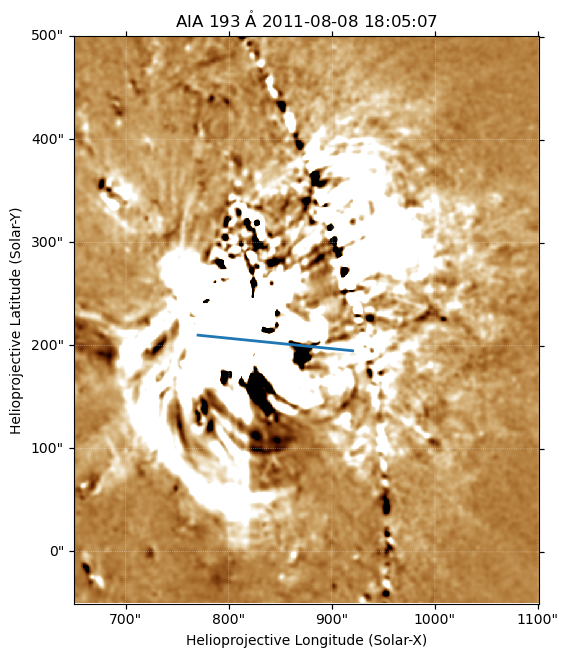

In [25]:
traced_loop = SkyCoord(
    Tx=[770, 920]*u.arcsec,
    Ty=[210, 195]*u.arcsec,
    frame=rd_sequence[0].coordinate_frame,
)

fig = plt.figure(figsize=(6, 10))
ax = fig.add_subplot(projection=rd_sequence[0])
rd_sequence[0].plot()
ax.plot_coord(traced_loop, lw=2)

In [26]:
traced_loop_pixelated = sunpy.map.pixelate_coord_path(rd_sequence[0], traced_loop)
traced_loop_pixelated

<SkyCoord (Helioprojective: obstime=2011-08-08T18:05:08.840, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2011-08-08T18:05:08.840, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.00016905, 6.26266904, 1.51656891e+11)>): (Tx, Ty) in arcsec
    [(769.83542743, 210.07316367), (770.43617676, 210.07375332),
     (771.03692608, 210.07434297), (771.63767539, 210.07493262),
     (772.23842468, 210.07552227), (772.23901662, 209.47476939),
     (772.8397659 , 209.47535905), (773.44051516, 209.4759487 ),
     (774.04126442, 209.47653834), (774.64201366, 209.47712799),
     (775.24276289, 209.47771764), (775.84351211, 209.47830728),
     (776.44426131, 209.47889692), (777.0450105 , 209.47948656),
     (777.64575967, 209.4800762 ), (778.24650884, 209.48066584),
     (778.24710077, 208.87991302), (778.84784992, 208.88050266),
     (779.44859905, 208.8810923 ), (780.04934818, 208.88168194),
     (780.65009729, 208.88227157), (781.25084638, 208.88286121),
     

In [27]:
traced_loop_distance = traced_loop_pixelated.separation(traced_loop_pixelated[0])
traced_loop_distance

<Angle [0.        , 0.00016687, 0.00033375, 0.00050062, 0.0006675 ,
        0.00068804, 0.0008509 , 0.00101506, 0.00117998, 0.00134539,
        0.00151112, 0.00167707, 0.00184319, 0.00200944, 0.00217578,
        0.0023422 , 0.00235997, 0.00252528, 0.00269078, 0.00285644,
        0.00302223, 0.00318814, 0.00335414, 0.00352023, 0.00368639,
        0.0038526 , 0.00401888, 0.00403616, 0.0042018 , 0.00436753,
        0.00453335, 0.00469924, 0.0048652 , 0.00503121, 0.00519729,
        0.00536341, 0.00552958, 0.00569579, 0.00571287, 0.00587864,
        0.00604446, 0.00621034, 0.00637628, 0.00654226, 0.00670828,
        0.00687435, 0.00704046, 0.0072066 , 0.00737277, 0.00738975,
        0.00755558, 0.00772145, 0.00788737, 0.00805333, 0.00821932,
        0.00838535, 0.00855142, 0.00871751, 0.00888363, 0.00904978,
        0.00906669, 0.00923257, 0.00939847, 0.00956441, 0.00973039,
        0.00989639, 0.01006242, 0.01022848, 0.01039457, 0.01056068,
        0.01057781, 0.01074368, 0.01090958, 0.01

In [28]:
intensity_stack = []
for m in rd_sequence:
    with SphericalScreen(m.observer_coordinate):
        _traced_loop_pixelated = sunpy.map.pixelate_coord_path(m, traced_loop)
    _traced_loop_distance = _traced_loop_pixelated.separation(_traced_loop_pixelated[0])
    intensity = sunpy.map.sample_at_coords(m, _traced_loop_pixelated)
    f_interp = interp1d(_traced_loop_distance.to_value('arcsec'), intensity.value, fill_value='extrapolate', kind='linear')
    intensity_interp = f_interp(traced_loop_distance.to_value('arcsec'))
    intensity_stack.append(u.Quantity(intensity_interp, intensity.unit))
intensity_stack = u.Quantity(intensity_stack)

In [29]:
time_array = [m.date.datetime for m in rd_sequence]
distance = traced_loop_distance.to(u.arcsec)

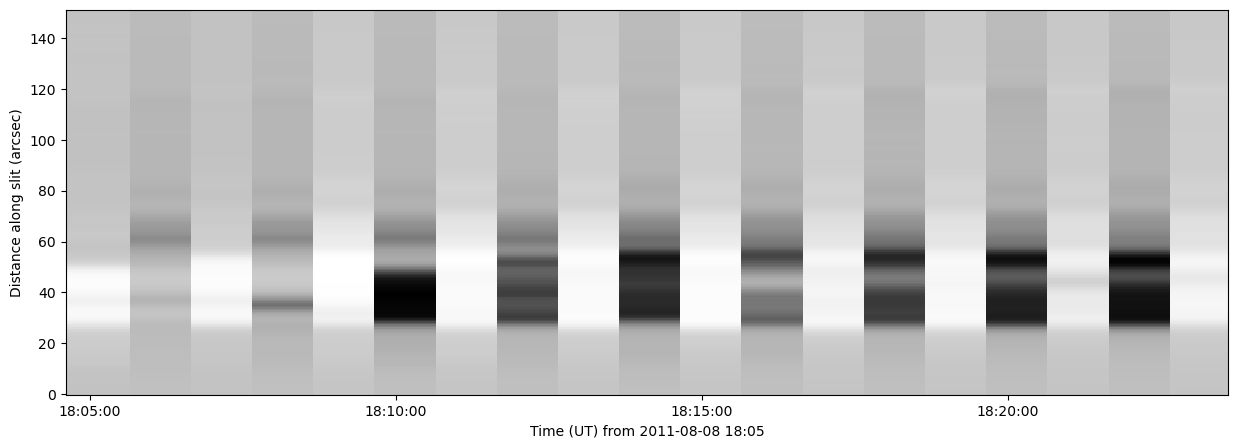

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.pcolormesh(time_array, distance.value, intensity_stack.value.T, 
               norm=ImageNormalize(stretch=AsinhStretch()), cmap="gray")

ax.set_ylabel("Distance along slit (arcsec)")
ax.set_xlabel("Time (UT) from {:s}".format(time_array[0].strftime("%Y-%m-%d %H:%M")))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M:%S"))

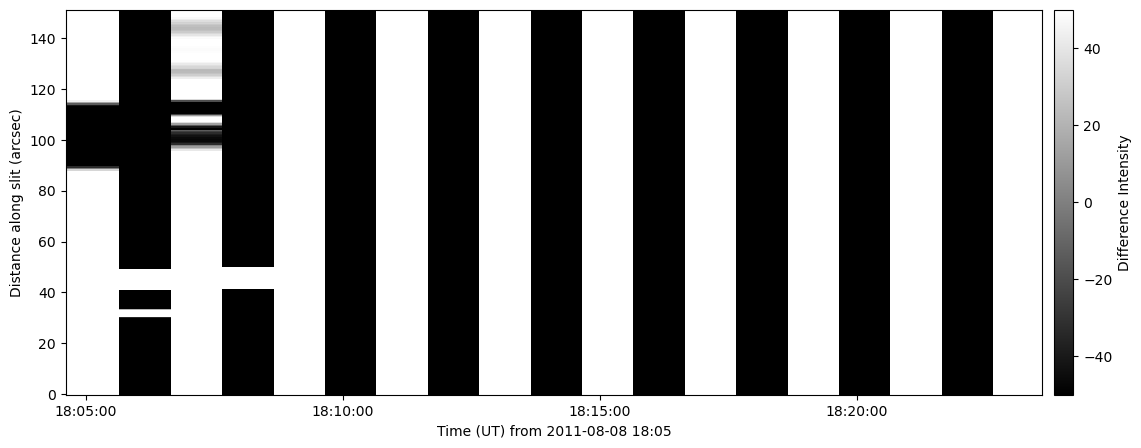

In [32]:
import matplotlib.pyplot as plt
from matplotlib import dates

fig, ax = plt.subplots(figsize=(15, 5))

# 1. Swapped AsinhStretch for the standard linear limits you used earlier
mesh = ax.pcolormesh(time_array, distance.value, intensity_stack.value.T, 
                     vmin=-50.0, vmax=50.0, cmap="gray")

ax.set_ylabel("Distance along slit (arcsec)")
ax.set_xlabel("Time (UT) from {:s}".format(time_array[0].strftime("%Y-%m-%d %H:%M")))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M:%S"))

# 2. Added a colorbar so you can read the difference values
plt.colorbar(mesh, ax=ax, label="Difference Intensity", pad=0.01)

plt.show()